# 02 · Model Development, Benchmark & Ensembles
**Phishing E-mail Detection: A Leakage-Controlled Benchmark of Classical, Deep and Transformer Models**  
*Part III · Sections 7-12* · MSc Data Science final project · Dr. Spoorthi H S

**In this notebook**
- One shared evaluation harness for every model
- Baselines: TF-IDF + Logistic Regression, TF-IDF + Linear SVM, BiLSTM (tuned on validation F1)
- Fine-tuned DistilBERT and RoBERTa-base on a Tesla T4 GPU, plus a LoRA efficiency variant
- Custom Attention-BiGRU fused with engineered features
- Out-of-fold stacked ensemble (primary) and extended heterogeneous stack (reference)

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline on a Kaggle Tesla T4 GPU. Every part builds on objects created earlier (the leak-free split, fitted models and their predictions), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Data, EDA & Leakage-Safe Split](01_data_eda_and_leakage_safe_split.ipynb) · [Statistical Evaluation, Calibration & Explainability →](03_statistical_evaluation_calibration_xai.ipynb)

---

<a id="partIII"></a>

<div style="background:#2A9D8F;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part III</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Model Development &amp; Benchmarking</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 7-12 &nbsp;&middot;&nbsp; Research questions: RQ1, RQ2, RQ3</div>
</div>


<a id="sec7"></a>

## 7. Shared Evaluation Harness

Every model in this notebook — classical, Transformer, or custom — is scored
by the same function, so the final comparison table is apples-to-apples.
**Recall is highlighted** because in a SOC (security operations centre)
context, a missed phishing email (false negative) is far costlier than a
false alarm.

### 7.1 Metric computation & result registry

`evaluate_model()` is the single place every model's val/test metrics are computed, printed, and stored in the shared `RESULTS` dict used by every comparison table for the rest of the notebook.

In [28]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report)

RESULTS = {}          # "<model>_val" / "<model>_test" -> metrics dict
FITTED_MODELS = {}    # model_name -> fitted object/handle (for later error analysis)

# --- Bookkeeping added in the distinction-level revision ---
# Rationale for this logic: see Appendix A (change log).
TRANSFORMER_CKPT_MAP = {}   # e.g. "roberta" -> "roberta_lr2e-05" (a run_name / folder stem)
_TRANSFORMER_MODEL_CACHE = {}  # (tokenizer, model) cache keyed by run_name, filled lazily

# Rationale for this logic: see Appendix A (change log).
MODEL_DISPLAY_NAMES = {
    "TFIDF_LogReg": "TF-IDF + Logistic Regression",
    "TFIDF_LinearSVM": "TF-IDF + Linear SVM",
    "BiLSTM": "BiLSTM",
    "distilbert": "DistilBERT",
    "roberta": "RoBERTa-base",
    "distilbert_lora": "DistilBERT + LoRA",
    "CustomHybridAttnBiGRU": "Custom Attention-BiGRU (fused)",
    "EnsembleStack": "Stacked Ensemble",
}
def display_name(model_key):
    return MODEL_DISPLAY_NAMES.get(model_key, model_key)

def evaluate_model(name, y_true, y_pred, y_proba=None, train_seconds=None, extra=None, verbose=True):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
            metrics["pr_auc"] = average_precision_score(y_true, y_proba)
        except ValueError:
            metrics["roc_auc"], metrics["pr_auc"] = float("nan"), float("nan")
    if train_seconds is not None:
        metrics["train_seconds"] = round(train_seconds, 2)
    if extra:
        metrics.update(extra)

    RESULTS[name] = metrics
    if verbose:
        print(f"\n=== {name} ===")
        for k, v in metrics.items():
            print(f"  {k:15s}: {v:.4f}" if isinstance(v, float) else f"  {k:15s}: {v}")
        # Rationale for this logic: see Appendix A (change log).
        print(classification_report(y_true, y_pred, labels=[0, 1],
                                     target_names=["legit", "phishing"], digits=3, zero_division=0))
    return metrics

### 7.2 Bootstrap confidence intervals & paired significance testing

Every point-estimate metric in this notebook (Section 11 onward) is accompanied
by a bootstrap confidence interval, and any "model A beats model B" claim is
backed by a **paired** bootstrap significance test on the same resampled test
indices (paired, because A and B are scored on the *same* held-out emails, so
pairing removes shared sampling noise and gives a fairer test than comparing
two independent confidence intervals by eye).

In [29]:
def bootstrap_ci(y_true, y_proba, metric_fn=f1_score, n_boot=None, ci=0.95, seed=SEED,
                  threshold=0.5, needs_proba=False):
    '''Percentile bootstrap CI for a classification metric on one model's predictions.
    metric_fn should accept (y_true, y_pred) unless needs_proba=True, in which case
    it is called as metric_fn(y_true, y_proba) (e.g. roc_auc_score).'''
    n_boot = n_boot or N_BOOTSTRAP
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true); y_proba = np.asarray(y_proba)
    n = len(y_true)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp = y_true[idx], y_proba[idx]
        if needs_proba:
            try:
                scores[b] = metric_fn(yt, yp)
            except ValueError:
                scores[b] = np.nan
        else:
            scores[b] = metric_fn(yt, (yp >= threshold).astype(int))
    scores = scores[~np.isnan(scores)]
    alpha = (1 - ci) / 2
    lo, hi = np.percentile(scores, [100 * alpha, 100 * (1 - alpha)])
    point = metric_fn(y_true, y_proba) if needs_proba else metric_fn(y_true, (y_proba >= threshold).astype(int))
    return {"point": point, "lo": lo, "hi": hi, "ci": ci, "n_boot": n_boot}

def paired_bootstrap_test(y_true, proba_a, proba_b, metric_fn=f1_score, n_boot=None,
                           seed=SEED, threshold=0.5, needs_proba=False):
    '''Paired bootstrap test for H0: metric(A) <= metric(B) (and the symmetric case),
    resampling the same indices for both models each iteration. Returns a two-sided
    p-value for 'A and B perform differently' plus the observed point difference.'''
    n_boot = n_boot or N_BOOTSTRAP
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true); proba_a = np.asarray(proba_a); proba_b = np.asarray(proba_b)
    n = len(y_true)
    diffs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, pa, pb = y_true[idx], proba_a[idx], proba_b[idx]
        if needs_proba:
            try:
                sa, sb = metric_fn(yt, pa), metric_fn(yt, pb)
            except ValueError:
                sa, sb = np.nan, np.nan
        else:
            sa = metric_fn(yt, (pa >= threshold).astype(int))
            sb = metric_fn(yt, (pb >= threshold).astype(int))
        diffs[b] = sa - sb
    diffs = diffs[~np.isnan(diffs)]
    observed = (diffs.mean())
    # two-sided p-value: proportion of bootstrap diffs that cross zero relative to the observed sign
    p_value = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    p_value = min(p_value, 1.0)
    return {"mean_diff": observed, "p_value": p_value, "n_boot": len(diffs)}

print("Bootstrap utilities ready: bootstrap_ci(), paired_bootstrap_test(). "
      f"Default resamples per call: N_BOOTSTRAP={N_BOOTSTRAP}.")


Bootstrap utilities ready: bootstrap_ci(), paired_bootstrap_test(). Default resamples per call: N_BOOTSTRAP=2000.


<a id="sec8"></a>

## 8. Classical & Deep-Learning Baseline Candidates

Three candidates, each **hyperparameter-tuned**, all trained on the same
leak-free split (Section 4) and the same cleaned text (Section 5):

1. TF-IDF + Logistic Regression
2. TF-IDF + Linear SVM (Platt-calibrated for probabilities)
3. BiLSTM (word-embedding based; no pretraining/attention)

At the end of this section we keep only the **top 2 by validation F1** as
finalists for the final benchmark.

### 8.1 Shared TF-IDF representation (fit on train only)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                         sublinear_tf=True, stop_words="english", min_df=3)
X_train_tfidf = tfidf.fit_transform(train_df["text_clean"])
X_val_tfidf = tfidf.transform(val_df["text_clean"])
X_test_tfidf = tfidf.transform(test_df["text_clean"])
print("TF-IDF matrix shape:", X_train_tfidf.shape)

TF-IDF matrix shape: (58280, 50000)


### 8.2 Candidate 1 — TF-IDF + Logistic Regression (tuned)

Small grid search over the regularisation strength `C`, selected by
validation F1.

In [31]:
from sklearn.linear_model import LogisticRegression

C_GRID = [0.1, 1.0, 3.0] if not QUICK_RUN else [0.5, 1.0]
best_logreg, best_logreg_f1, best_logreg_c = None, -1, None
t0 = time.time()
for C in C_GRID:
    clf = LogisticRegression(max_iter=2000, C=C, class_weight="balanced", random_state=SEED)
    clf.fit(X_train_tfidf, y_train)
    f1 = f1_score(y_val, clf.predict(X_val_tfidf))
    print(f"  C={C:<5} val_f1={f1:.4f}")
    if f1 > best_logreg_f1:
        best_logreg, best_logreg_f1, best_logreg_c = clf, f1, C
train_time = time.time() - t0
print(f"Best C={best_logreg_c} (val F1={best_logreg_f1:.4f})")

logreg = best_logreg
FITTED_MODELS["TFIDF_LogReg"] = logreg

val_proba = logreg.predict_proba(X_val_tfidf)[:, 1]
evaluate_model("TFIDF_LogReg_val", y_val, (val_proba >= 0.5).astype(int), val_proba, train_time,
               {"best_C": best_logreg_c})
test_proba = logreg.predict_proba(X_test_tfidf)[:, 1]
evaluate_model("TFIDF_LogReg_test", y_test, (test_proba >= 0.5).astype(int), test_proba, train_time,
               {"best_C": best_logreg_c})

  C=0.1   val_f1=0.9729
  C=1.0   val_f1=0.9848
  C=3.0   val_f1=0.9859
Best C=3.0 (val F1=0.9859)

=== TFIDF_LogReg_val ===
  accuracy       : 0.9864
  precision      : 0.9845
  recall         : 0.9873
  f1             : 0.9859
  roc_auc        : 0.9988
  pr_auc         : 0.9987
  train_seconds  : 8.0700
  best_C         : 3.0000
              precision    recall  f1-score   support

       legit      0.988     0.986     0.987      5973
    phishing      0.984     0.987     0.986      5530

    accuracy                          0.986     11503
   macro avg      0.986     0.986     0.986     11503
weighted avg      0.986     0.986     0.986     11503


=== TFIDF_LogReg_test ===
  accuracy       : 0.9845
  precision      : 0.9837
  recall         : 0.9862
  f1             : 0.9849
  roc_auc        : 0.9987
  pr_auc         : 0.9986
  train_seconds  : 8.0700
  best_C         : 3.0000
              precision    recall  f1-score   support

       legit      0.985     0.983     0.984      5

{'accuracy': 0.9844743579156,
 'precision': 0.9836643177450353,
 'recall': 0.9861913937058445,
 'f1': 0.9849262347658756,
 'roc_auc': np.float64(0.9986600819922686),
 'pr_auc': np.float64(0.9986459890219237),
 'train_seconds': 8.07,
 'best_C': 3.0}

### 8.3 Candidate 2 — TF-IDF + Linear SVM (tuned)

`LinearSVC` has no native `predict_proba`; it's wrapped in Platt scaling
(`CalibratedClassifierCV`) for comparable probabilities.

In [32]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

best_svm, best_svm_f1, best_svm_c = None, -1, None
t0 = time.time()
for C in C_GRID:
    base_svm = LinearSVC(C=C, class_weight="balanced", random_state=SEED, max_iter=5000)
    cal_svm = CalibratedClassifierCV(base_svm, method="sigmoid", cv=3)
    cal_svm.fit(X_train_tfidf, y_train)
    f1 = f1_score(y_val, cal_svm.predict(X_val_tfidf))
    print(f"  C={C:<5} val_f1={f1:.4f}")
    if f1 > best_svm_f1:
        best_svm, best_svm_f1, best_svm_c = cal_svm, f1, C
train_time = time.time() - t0
print(f"Best C={best_svm_c} (val F1={best_svm_f1:.4f})")

svm_calibrated = best_svm
FITTED_MODELS["TFIDF_LinearSVM"] = svm_calibrated

val_proba = svm_calibrated.predict_proba(X_val_tfidf)[:, 1]
evaluate_model("TFIDF_LinearSVM_val", y_val, (val_proba >= 0.5).astype(int), val_proba, train_time,
               {"best_C": best_svm_c})
test_proba = svm_calibrated.predict_proba(X_test_tfidf)[:, 1]
evaluate_model("TFIDF_LinearSVM_test", y_test, (test_proba >= 0.5).astype(int), test_proba, train_time,
               {"best_C": best_svm_c})

  C=0.1   val_f1=0.9851
  C=1.0   val_f1=0.9894
  C=3.0   val_f1=0.9891
Best C=1.0 (val F1=0.9894)

=== TFIDF_LinearSVM_val ===
  accuracy       : 0.9898
  precision      : 0.9883
  recall         : 0.9906
  f1             : 0.9894
  roc_auc        : 0.9990
  pr_auc         : 0.9989
  train_seconds  : 6.2100
  best_C         : 1.0000
              precision    recall  f1-score   support

       legit      0.991     0.989     0.990      5973
    phishing      0.988     0.991     0.989      5530

    accuracy                          0.990     11503
   macro avg      0.990     0.990     0.990     11503
weighted avg      0.990     0.990     0.990     11503


=== TFIDF_LinearSVM_test ===
  accuracy       : 0.9879
  precision      : 0.9878
  recall         : 0.9886
  f1             : 0.9882
  roc_auc        : 0.9992
  pr_auc         : 0.9992
  train_seconds  : 6.2100
  best_C         : 1.0000
              precision    recall  f1-score   support

       legit      0.988     0.987     0.987 

{'accuracy': 0.9878602692212404,
 'precision': 0.987806834590085,
 'recall': 0.9885998715478485,
 'f1': 0.9882031939651713,
 'roc_auc': np.float64(0.9991566300454627),
 'pr_auc': np.float64(0.9991859448731951),
 'train_seconds': 6.21,
 'best_C': 1.0}

### 8.4 Candidate 3 — BiLSTM (tuned)

The bridge between bag-of-words models and Transformers: it can learn word
order via recurrence, but has no pretraining or attention. A small grid
over hidden size and learning rate is evaluated by validation F1.

In [33]:
if TORCH_AVAILABLE:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from collections import Counter

    MAX_VOCAB = 30000
    MAX_LEN = 60 if QUICK_RUN else 200   # smoke-test mode uses a much shorter
                                          # sequence length so training stays fast
                                          # even on CPU-only / single-core hardware.

    def simple_tokenize(text):
        return text.split()

    counter = Counter()
    for t in train_df["text_clean"]:
        counter.update(simple_tokenize(t))
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, _ in counter.most_common(MAX_VOCAB - 2):
        vocab[word] = len(vocab)

    def encode(text, max_len=MAX_LEN):
        tokens = simple_tokenize(text)[:max_len]
        ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
        ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
        return ids

    class EmailDataset(Dataset):
        def __init__(self, df):
            self.X = [encode(t) for t in df["text_clean"]]
            self.y = df["label"].values.astype(np.float32)
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return torch.tensor(self.X[idx], dtype=torch.long), torch.tensor(self.y[idx])

    train_ds, val_ds, test_ds = EmailDataset(train_df), EmailDataset(val_df), EmailDataset(test_df)
    train_loader = DataLoader(train_ds, batch_size=(128 if QUICK_RUN else 64), shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128)
    test_loader = DataLoader(test_ds, batch_size=128)
    print("Vocab size:", len(vocab))

    class BiLSTMClassifier(nn.Module):
        def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_dim * 2, 1)
        def forward(self, x):
            emb = self.embedding(x)
            _, (h_n, _) = self.lstm(emb)
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)
            return self.fc(self.dropout(h)).squeeze(-1)

    def run_epoch(model, loader, optimizer, criterion, device, train=True):
        model.train() if train else model.eval()
        total_loss, all_logits, all_labels = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                total_loss += loss.item() * xb.size(0)
                all_logits.append(logits.detach().cpu())
                all_labels.append(yb.detach().cpu())
        return (total_loss / len(loader.dataset),
                torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy())

    HP_GRID_BILSTM = ([{"hidden_dim": 64, "lr": 1e-3}] if QUICK_RUN else
                      ([{"hidden_dim": 128, "lr": 1e-3}, {"hidden_dim": 256, "lr": 5e-4}]
                       if RUN_HP_SEARCH else [{"hidden_dim": 128, "lr": 1e-3}]))
    # QUICK_RUN forces a single small config -- the smoke test should stay fast
    # regardless of RUN_HP_SEARCH, which is meant to control grid size only for a real run.
    EPOCHS_BILSTM = 2 if QUICK_RUN else 6

    best_bilstm, best_bilstm_f1, best_bilstm_cfg, best_n_params = None, -1, None, None
    t0 = time.time()
    for cfg in HP_GRID_BILSTM:
        torch.manual_seed(SEED)
        model = BiLSTMClassifier(len(vocab), hidden_dim=cfg["hidden_dim"]).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
        criterion = nn.BCEWithLogitsLoss()
        n_params = sum(p.numel() for p in model.parameters())

        cfg_best_f1 = -1
        for epoch in range(1, EPOCHS_BILSTM + 1):
            train_loss, _, _ = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
            val_loss, val_logits, val_labels = run_epoch(model, val_loader, optimizer, criterion, DEVICE, train=False)
            val_pred = (1 / (1 + np.exp(-val_logits)) >= 0.5).astype(int)
            f1 = f1_score(val_labels, val_pred)
            print(f"  cfg={cfg} epoch {epoch}/{EPOCHS_BILSTM} train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_f1={f1:.4f}")
            if f1 > cfg_best_f1:
                cfg_best_f1 = f1
                torch.save(model.state_dict(), WORKING_DIR / "models" / "bilstm_tmp.pt")
        if cfg_best_f1 > best_bilstm_f1:
            best_bilstm_f1 = cfg_best_f1
            best_bilstm_cfg = cfg
            best_n_params = n_params
            model.load_state_dict(torch.load(WORKING_DIR / "models" / "bilstm_tmp.pt"))
            best_bilstm = model
    train_time = time.time() - t0
    print(f"Best BiLSTM config: {best_bilstm_cfg} (val F1={best_bilstm_f1:.4f})")

    bilstm_model = best_bilstm
    FITTED_MODELS["BiLSTM"] = bilstm_model
    criterion = nn.BCEWithLogitsLoss()

    _, val_logits, val_labels = run_epoch(bilstm_model, val_loader, None, criterion, DEVICE, train=False)
    val_proba = 1 / (1 + np.exp(-val_logits))
    evaluate_model("BiLSTM_val", val_labels, (val_proba >= 0.5).astype(int), val_proba, train_time,
                   {"n_params": best_n_params, "config": str(best_bilstm_cfg)})

    _, test_logits, test_labels = run_epoch(bilstm_model, test_loader, None, criterion, DEVICE, train=False)
    test_proba = 1 / (1 + np.exp(-test_logits))
    evaluate_model("BiLSTM_test", test_labels, (test_proba >= 0.5).astype(int), test_proba, train_time,
                   {"n_params": best_n_params, "config": str(best_bilstm_cfg)})
else:
    print("[INFO] torch is not installed -- skipping the BiLSTM baseline (Section 8.4). "
          "The rest of the notebook degrades gracefully: BiLSTM is simply "
          "left out of the top-2 baseline selection (Section 8.5) and any "
          "later comparison that depends on it.")


Vocab size: 30000
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 1/6 train_loss=0.1734 val_loss=0.0925 val_f1=0.9682
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 2/6 train_loss=0.0595 val_loss=0.0913 val_f1=0.9755
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 3/6 train_loss=0.0352 val_loss=0.0596 val_f1=0.9826
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 4/6 train_loss=0.0164 val_loss=0.0620 val_f1=0.9820
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 5/6 train_loss=0.0110 val_loss=0.0707 val_f1=0.9839
  cfg={'hidden_dim': 128, 'lr': 0.001} epoch 6/6 train_loss=0.0067 val_loss=0.0698 val_f1=0.9841
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 1/6 train_loss=0.1914 val_loss=0.1084 val_f1=0.9622
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 2/6 train_loss=0.0823 val_loss=0.0860 val_f1=0.9707
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 3/6 train_loss=0.0613 val_loss=0.0916 val_f1=0.9693
  cfg={'hidden_dim': 256, 'lr': 0.0005} epoch 4/6 train_loss=0.0364 val_loss=0.0689 val_f1=0.9766
  cfg={'

### 8.5 Select the top 2 baselines

Ranked by **validation** F1 (never test — test stays untouched until the
final comparison) so the selection itself can't leak test information.

In [34]:
baseline_names = ["TFIDF_LogReg", "TFIDF_LinearSVM", "BiLSTM"]
# Tolerate a baseline that could not be trained in this environment (e.g. BiLSTM
# when torch is unavailable -- see the TORCH_AVAILABLE guard in Section 8.4)
# instead of a hard KeyError.
baseline_names = [n for n in baseline_names if f"{n}_val" in RESULTS]
baseline_val_f1 = {name: RESULTS[f"{name}_val"]["f1"] for name in baseline_names}
print("Baseline candidates (validation F1):")
for name, f1 in sorted(baseline_val_f1.items(), key=lambda x: -x[1]):
    print(f"  {name:20s} {f1:.4f}")

TOP2_BASELINES = [n for n, _ in sorted(baseline_val_f1.items(), key=lambda x: -x[1])[:2]]
print(f"\nTop-2 baselines carried forward: {TOP2_BASELINES}")

Baseline candidates (validation F1):
  TFIDF_LinearSVM      0.9894
  TFIDF_LogReg         0.9859
  BiLSTM               0.9841

Top-2 baselines carried forward: ['TFIDF_LinearSVM', 'TFIDF_LogReg']


<a id="sec9"></a>

## 9. Pretrained Transformer Candidates

Two fine-tuned Transformer encoders, all on the same leak-free split and
the same `compute_metrics`/caching infrastructure. Set `RUN_TRANSFORMERS =
False` in Section 1 to skip this (e.g. no GPU/internet available) — the rest
of the notebook still runs using cached or previously-saved results if
present.

1. `distilbert-base-uncased` — fast, distilled baseline Transformer.
2. `roberta-base` — stronger pretraining objective, no NSP, larger.

Each is fine-tuned with a **small learning-rate grid** (when
`RUN_HP_SEARCH=True`), and results are cached to disk so an interrupted run
doesn't force retraining a model that already finished.

> **Execution note.** Section 9 was executed on a Kaggle GPU (Tesla T4) with Hugging Face Hub access and `QUICK_RUN = False`. **DistilBERT and RoBERTa-base trained successfully and are the two Transformer finalists.**

In [35]:
CHECKPOINT_KEYWORDS = {
    "distilbert-base-uncased": "distilbert",
    "roberta-base": "roberta",
}

def _hub_reachable(host="huggingface.co", timeout=5):
    # True if the Hugging Face Hub can actually be reached from this runtime -- not just
    # 'is the transformers package importable', which says nothing about network access.
    # Rationale for this logic: see Appendix A (change log).
    import socket
    try:
        socket.setdefaulttimeout(timeout)
        socket.gethostbyname(host)
        with socket.create_connection((host, 443), timeout=timeout):
            return True
    except OSError:
        return False

def _kaggle_input_for(model_checkpoint):
    # Look for a locally-attached Kaggle Model/Dataset input -- the standard way to get
    # pretrained weights into a Kaggle notebook that has internet turned off: Add Input ->
    # search Kaggle Models -> attach e.g. the Hugging Face-published 'distilbert-base-
    # uncased' model. Matches by keyword against every directory under /kaggle/input/ that
    # contains a config.json, so it works regardless of the exact slug the input was
    # attached under.
    keyword = CHECKPOINT_KEYWORDS.get(model_checkpoint, model_checkpoint.split("/")[-1])
    for config_path in glob.glob("/kaggle/input/**/config.json", recursive=True):
        d = os.path.dirname(config_path)
        if keyword.lower() in d.lower():
            return d
    return None

def resolve_checkpoint_source(model_checkpoint):
    # Return (source_path_or_hub_id, origin_label) -- prefer a live Hub download (always
    # the freshest weights) and fall back to a locally-attached Kaggle Model/Dataset input
    # if the Hub is unreachable. Raises RuntimeError with an actionable message if neither
    # is available, rather than failing deep inside Trainer.train().
    if HUB_REACHABLE:
        return model_checkpoint, "huggingface.co"
    local = _kaggle_input_for(model_checkpoint)
    if local is not None:
        return local, "kaggle input"
    raise RuntimeError(
        f"Cannot obtain weights for '{model_checkpoint}': huggingface.co is unreachable "
        f"from this runtime and no matching folder was found under /kaggle/input/. "
        f"Either enable internet for this session (Hub access), or attach the matching "
        f"model as a Kaggle Model/Dataset input (Add Input -> search Kaggle Models -> "
        f"e.g. Hugging Face's '{model_checkpoint}') and re-run.")

if RUN_TRANSFORMERS:
    try:
        import transformers, datasets, accelerate  # noqa: F401
    except ImportError as e:
        print(f"[INFO] transformers/datasets/accelerate not installed ({e}) -- "
              "skipping Section 9's Transformer training cells. Install with:\n"
              "  pip install -q transformers datasets evaluate accelerate sentencepiece\n"
              "and re-run from here if you want the Transformer finalists included.")
        RUN_TRANSFORMERS = False
    else:
        print("transformers:", transformers.__version__)
        HUB_REACHABLE = _hub_reachable()
        if HUB_REACHABLE:
            print("[OK] huggingface.co is reachable -- weights will be downloaded from the Hub.")
        else:
            n_local = sum(1 for k in CHECKPOINT_KEYWORDS if _kaggle_input_for(k) is not None)
            if n_local == len(CHECKPOINT_KEYWORDS):
                print("[OK] huggingface.co is NOT reachable, but all 3 checkpoints were found "
                      "under /kaggle/input/ -- weights will be loaded from there instead.")
            elif n_local > 0:
                print(f"[WARN] huggingface.co is NOT reachable, and only {n_local}/"
                      f"{len(CHECKPOINT_KEYWORDS)} checkpoints were found under /kaggle/input/. "
                      "The missing one(s) will raise a clear error when their training cell runs "
                      "-- attach them as Kaggle Model inputs to fix this.")
            else:
                print("[INFO] huggingface.co is NOT reachable and no matching checkpoints were "
                      "found under /kaggle/input/ -- disabling RUN_TRANSFORMERS for this run. "
                      "Either enable internet access for this session, or attach "
                      "distilbert-base-uncased / roberta-base as "
                      "Kaggle Model inputs and re-run from Section 9.")
                RUN_TRANSFORMERS = False
else:
    print("RUN_TRANSFORMERS is False -- skipping Section 9's training cells.")


transformers: 5.0.0
[OK] huggingface.co is reachable -- weights will be downloaded from the Hub.


In [36]:
if RUN_TRANSFORMERS:
    from datasets import Dataset as HFDataset, DatasetDict  # aliased: avoid shadowing torch.utils.data.Dataset
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               TrainingArguments, Trainer, EarlyStoppingCallback)
    from sklearn.metrics import precision_recall_fscore_support
    import inspect

    def to_hf_dataset(df):
        return HFDataset.from_pandas(
            df[["text_clean", "label"]].rename(columns={"text_clean": "text"}),
            preserve_index=False)

    raw_datasets = DatasetDict({
        "train": to_hf_dataset(train_df),
        "validation": to_hf_dataset(val_df),
        "test": to_hf_dataset(test_df),
    })

    RESULTS_DIR = WORKING_DIR / "results"

    def _results_path(run_name):
        return RESULTS_DIR / f"{run_name}_results.json"

    def load_cached_results(run_name):
        p = _results_path(run_name)
        return json.load(open(p)) if p.exists() else None

    def save_results(run_name, results):
        json.dump(results, open(_results_path(run_name), "w"), indent=2)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        logits = np.asarray(logits, dtype=np.float64)
        n_bad = int(np.isnan(logits).sum() + np.isinf(logits).sum())
        if n_bad:
            logits = np.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)
        probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
        preds = np.argmax(logits, axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="binary", zero_division=0)
        metrics = {"accuracy": accuracy_score(labels, preds),
                   "precision": precision, "recall": recall, "f1": f1}
        try:
            metrics["roc_auc"] = roc_auc_score(labels, probs)
        except ValueError:
            metrics["roc_auc"] = float("nan")
        try:
            metrics["pr_auc"] = average_precision_score(labels, probs)
        except ValueError:
            metrics["pr_auc"] = float("nan")
        return metrics

    def _make_training_args(run_name, lr, batch_size, epochs, fp16, load_best=True):
        common = dict(
            output_dir=str(WORKING_DIR / "models" / f"{run_name}_ckpt"),
            save_strategy="epoch", learning_rate=lr,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size * 2,
            num_train_epochs=epochs, weight_decay=0.01,
            load_best_model_at_end=load_best, metric_for_best_model="f1",
            greater_is_better=True, logging_steps=100, save_total_limit=1,
            report_to="none", fp16=fp16, seed=SEED,
        )
        try:
            return TrainingArguments(eval_strategy="epoch", **common)
        except TypeError:
            return TrainingArguments(evaluation_strategy="epoch", **common)

    def _make_trainer(model, args, train_ds, eval_ds, tokenizer, early_stop=True):
        kwargs = dict(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds,
                       compute_metrics=compute_metrics,
                       callbacks=([EarlyStoppingCallback(early_stopping_patience=2)] if early_stop else []))
        sig = inspect.signature(Trainer.__init__).parameters
        kwargs["processing_class" if "processing_class" in sig else "tokenizer"] = tokenizer
        return Trainer(**kwargs)

    def train_transformer(model_checkpoint, run_name, max_length=256, epochs=3,
                           lr=2e-5, batch_size=16, force_retrain=False):
        cached = None if force_retrain else load_cached_results(run_name)
        if cached is not None:
            print(f"[cache] Using saved results for '{run_name}'.")
            return None, cached

        checkpoint_source, origin = resolve_checkpoint_source(model_checkpoint)
        print(f"\n{'='*70}\nTraining {run_name} ({model_checkpoint}, weights from {origin}) "
              f"lr={lr} epochs={epochs}\n{'='*70}")
        try:
            tokenizer = AutoTokenizer.from_pretrained(checkpoint_source)
        except Exception as e:
            print(f"[WARN] Fast tokenizer failed ({e}); falling back to use_fast=False.")
            tokenizer = AutoTokenizer.from_pretrained(checkpoint_source, use_fast=False)

        def tokenize_fn(batch):
            return tokenizer(batch["text"], truncation=True, max_length=max_length, padding="max_length")

        tokenized = raw_datasets.map(tokenize_fn, batched=True)
        tokenized = tokenized.remove_columns(["text"]).rename_column("label", "labels")
        tokenized.set_format("torch")

        def _build(fp16):
            model = AutoModelForSequenceClassification.from_pretrained(checkpoint_source, num_labels=2)
            # DeBERTa-v2/v3: do NOT reload the best checkpoint (LayerNorm gamma/beta key mismatch, see Section 9.3)
            args = _make_training_args(run_name, lr, batch_size, epochs, fp16=fp16, load_best=not fp16_unsafe)
            return model, _make_trainer(model, args, tokenized["train"], tokenized["validation"], tokenizer, early_stop=not fp16_unsafe)

        fp16_unsafe = any(tag in model_checkpoint.lower() for tag in ("deberta-v2", "deberta-v3"))
        use_fp16 = torch.cuda.is_available() and not fp16_unsafe
        model, trainer = _build(use_fp16)

        t0 = time.time()
        try:
            trainer.train()
        except ValueError as e:
            if use_fp16 and "unscale FP16 gradients" in str(e):
                print(f"[WARN] {run_name}: fp16 instability, retrying in fp32.")
                model, trainer = _build(False)
                trainer.train()
            else:
                raise
        train_time = time.time() - t0

        def _strip(metrics, prefix="eval_"):
            return {(k[len(prefix):] if k.startswith(prefix) else k): v for k, v in metrics.items()}

        val_metrics = _strip(trainer.evaluate(tokenized["validation"]))
        test_metrics = _strip(trainer.evaluate(tokenized["test"]))
        n_params = sum(p.numel() for p in model.parameters())
        for m in (val_metrics, test_metrics):
            m["train_seconds"] = round(train_time, 2)
            m["n_params"] = n_params

        results = {f"{run_name}_val": val_metrics, f"{run_name}_test": test_metrics}
        save_results(run_name, results)
        return trainer, results

### 9.1 DistilBERT

In [37]:
if RUN_TRANSFORMERS:
    LR_GRID_DISTILBERT = [2e-5, 5e-5] if RUN_HP_SEARCH else [2e-5]
    epochs = 1 if QUICK_RUN else 3
    best_result, best_f1, best_lr = None, -1, None
    for lr in LR_GRID_DISTILBERT:
        _, res = train_transformer("distilbert-base-uncased", f"distilbert_lr{lr}",
                                    max_length=256, epochs=epochs, lr=lr, batch_size=32)
        f1 = res[[k for k in res if k.endswith('_val')][0]]["f1"]
        if f1 > best_f1:
            best_f1, best_result, best_lr = f1, res, lr
    distilbert_results = {k.replace(f"_lr{best_lr}", ""): v for k, v in best_result.items()}
    TRANSFORMER_CKPT_MAP["distilbert"] = f"distilbert_lr{best_lr}"
    # Rationale for this logic: see Appendix A (change log).
    print(f"Best DistilBERT lr={best_lr}, val F1={best_f1:.4f}")


Training distilbert_lr2e-05 (distilbert-base-uncased, weights from huggingface.co) lr=2e-05 epochs=3


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Best DistilBERT lr=5e-05, val F1=0.9920


### 9.2 RoBERTa-base

In [38]:
if RUN_TRANSFORMERS:
    LR_GRID_ROBERTA = [1e-5, 2e-5] if RUN_HP_SEARCH else [2e-5]
    epochs = 1 if QUICK_RUN else 3
    best_result, best_f1, best_lr = None, -1, None
    for lr in LR_GRID_ROBERTA:
        _, res = train_transformer("roberta-base", f"roberta_lr{lr}",
                                    max_length=256, epochs=epochs, lr=lr, batch_size=16)
        f1 = res[[k for k in res if k.endswith('_val')][0]]["f1"]
        if f1 > best_f1:
            best_f1, best_result, best_lr = f1, res, lr
    roberta_results = {k.replace(f"_lr{best_lr}", ""): v for k, v in best_result.items()}
    TRANSFORMER_CKPT_MAP["roberta"] = f"roberta_lr{best_lr}"
    # Rationale for this logic: see Appendix A (change log).
    print(f"Best RoBERTa lr={best_lr}, val F1={best_f1:.4f}")


Training roberta_lr1e-05 (roberta-base, weights from huggingface.co) lr=1e-05 epochs=3


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Best RoBERTa lr=2e-05, val F1=0.9931


### 9.4 Select the top 2 Transformers

Same rule as the baselines: rank the fine-tuned candidates by
**validation** F1 (with only two Transformer candidates now, both are kept).

In [39]:
if RUN_TRANSFORMERS:
    for run_name, res in [("distilbert", distilbert_results),
                            ("roberta", roberta_results)]:
        for k, v in res.items():
            RESULTS[k] = v

    transformer_names = ["distilbert", "roberta"]
    transformer_val_f1 = {name: RESULTS[f"{name}_val"]["f1"] for name in transformer_names}
    print("Transformer candidates (validation F1):")
    for name, f1 in sorted(transformer_val_f1.items(), key=lambda x: -x[1]):
        print(f"  {name:15s} {f1:.4f}")

    TOP2_TRANSFORMERS = [n for n, _ in sorted(transformer_val_f1.items(), key=lambda x: -x[1])[:2]]
    print(f"\nTop-2 Transformers carried forward: {TOP2_TRANSFORMERS}")
else:
    TOP2_TRANSFORMERS = []
    print("RUN_TRANSFORMERS is False -- no Transformer finalists this run. "
          "The final benchmark table (Section 11) will note this gap.")

Transformer candidates (validation F1):
  roberta         0.9931
  distilbert      0.9920

Top-2 Transformers carried forward: ['roberta', 'distilbert']


### 9.5 Parameter-efficient fine-tuning (LoRA)

A fourth Transformer variant: `distilbert-base-uncased` fine-tuned with **LoRA**
(Low-Rank Adaptation) instead of full fine-tuning. Only small rank-decomposition
adapter matrices are trained; the base model's weights stay frozen. This is the
efficiency-vs-accuracy trade-off item for this benchmark: we expect LoRA to train
faster and use less memory than full fine-tuning (Section 9.1), at a small
(hopefully negligible) accuracy cost -- exactly the kind of trade-off worth
knowing about before choosing a production model (see also Section 23,
efficiency benchmarking, for the same trade-off measured directly in latency/
memory rather than training cost).

In [40]:
!pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [41]:
lora_results = {}

if RUN_TRANSFORMERS and RUN_LORA:
    try:
        from peft import LoraConfig, get_peft_model, TaskType
    except ImportError:
        print("[INFO] `peft` is not installed -- skipping LoRA fine-tuning. "
              "Install with: pip install -q peft")
        RUN_LORA = False

if RUN_TRANSFORMERS and RUN_LORA:
    def train_lora_transformer(model_checkpoint, run_name, max_length=256, epochs=None,
                                lr=2e-4, batch_size=32, lora_r=8, lora_alpha=16,
                                lora_dropout=0.1, force_retrain=False):
        '''Same evaluation contract as train_transformer(), but wraps the base
        encoder in a frozen-backbone + trainable LoRA-adapter configuration.'''
        epochs = epochs if epochs is not None else (1 if QUICK_RUN else 3)
        cached = None if force_retrain else load_cached_results(run_name)
        if cached is not None:
            print(f"[cache] Using saved results for '{run_name}'.")
            return None, cached

        print(f"\n{'='*70}\nLoRA fine-tuning {run_name} ({model_checkpoint}) "
              f"r={lora_r} alpha={lora_alpha} lr={lr} epochs={epochs}\n{'='*70}")
        tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

        def tokenize_fn(batch):
            return tokenizer(batch["text"], truncation=True, max_length=max_length, padding="max_length")

        tokenized = raw_datasets.map(tokenize_fn, batched=True)
        tokenized = tokenized.remove_columns(["text"]).rename_column("label", "labels")
        tokenized.set_format("torch")

        base_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)
        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS, r=lora_r, lora_alpha=lora_alpha,
            lora_dropout=lora_dropout, target_modules=["q_lin", "v_lin"],  # DistilBERT attention proj.
        )
        model = get_peft_model(base_model, lora_cfg)
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in model.parameters())
        print(f"Trainable params: {n_trainable:,} / {n_total:,} "
              f"({n_trainable / n_total:.2%} of the base model)")

        args = _make_training_args(run_name, lr, batch_size, epochs, fp16=torch.cuda.is_available())
        trainer = _make_trainer(model, args, tokenized["train"], tokenized["validation"], tokenizer)

        t0 = time.time()
        trainer.train()
        train_time = time.time() - t0

        def _strip(metrics, prefix="eval_"):
            return {(k[len(prefix):] if k.startswith(prefix) else k): v for k, v in metrics.items()}

        val_metrics = _strip(trainer.evaluate(tokenized["validation"]))
        test_metrics = _strip(trainer.evaluate(tokenized["test"]))
        for m in (val_metrics, test_metrics):
            m["train_seconds"] = round(train_time, 2)
            m["n_params"] = n_trainable          # trainable (adapter) params, the honest efficiency figure
            m["n_params_total"] = n_total

        results = {f"{run_name}_val": val_metrics, f"{run_name}_test": test_metrics}
        save_results(run_name, results)
        return trainer, results

    _, lora_results = train_lora_transformer("distilbert-base-uncased", "distilbert_lora")
    RESULTS.update(lora_results)
    TRANSFORMER_CKPT_MAP["distilbert_lora"] = "distilbert_lora"  # see Section 9.1-9.3 note.

    if "distilbert_val" in RESULTS:
        comp = pd.DataFrame({
            "full_fine_tune": RESULTS["distilbert_val"],
            "lora": RESULTS["distilbert_lora_val"],
        })
        print("\nFull fine-tuning vs. LoRA (validation set):")
        print(comp.loc[[c for c in ["f1", "recall", "train_seconds", "n_params"] if c in comp.index]]
              .round(4).to_string())
else:
    print("RUN_TRANSFORMERS/RUN_LORA is False -- skipping LoRA fine-tuning. "
          "lora_results stays an empty dict.")



LoRA fine-tuning distilbert_lora (distilbert-base-uncased) r=8 alpha=16 lr=0.0002 epochs=3


Map:   0%|          | 0/58280 [00:00<?, ? examples/s]

Map:   0%|          | 0/11503 [00:00<?, ? examples/s]

Map:   0%|          | 0/12109 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Trainable params: 739,586 / 67,694,596 (1.09% of the base model)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Pr Auc
1,0.115574,0.104286,0.980961,0.981505,0.978843,0.980172,0.998234,0.998075
2,0.066842,0.091228,0.983656,0.988836,0.977034,0.982900,0.998871,0.998784
3,0.057755,0.077784,0.986091,0.989071,0.981917,0.985481,0.999097,0.999031



Full fine-tuning vs. LoRA (validation set):
               full_fine_tune         lora
f1               9.920000e-01       0.9855
recall           9.922000e-01       0.9819
train_seconds    2.269620e+03    1809.8200
n_params         6.695501e+07  739586.0000


<a id="sec10"></a>

## 10. Custom Model — Attention-BiGRU Fused with Engineered Features

This is a from-scratch architecture (no pretrained checkpoint), designed
specifically to combine the two signal types explored above:

- A **BiGRU encoder** over the cleaned token sequence, pooled with a learned
  **additive attention** layer (rather than just taking the last hidden
  state, like the BiLSTM baseline) — attention weights also give a cheap
  form of interpretability (which tokens drove the decision).
- The Section 6 **engineered feature vector** (URL/urgency-keyword counts,
  length stats, punctuation/caps ratios), fed through a small dense branch.
- The attention-pooled text representation and the engineered-feature
  representation are **concatenated** and passed through a final classifier
  head.

Rationale: the classical baselines only see bag-of-words signal, and the
Transformers only see raw subword sequences — neither is explicitly given
the stylometric cues (e.g. "6 urgency words and 3 links") that Section 6
showed are correlated with the label. This model is a genuine architectural
alternative, not a re-parameterisation of the BiLSTM baseline.

In [42]:
if TORCH_AVAILABLE:
    class AdditiveAttention(nn.Module):
        def __init__(self, hidden_dim):
            super().__init__()
            self.attn = nn.Linear(hidden_dim, 1)
        def forward(self, seq_out, mask):
            # seq_out: (B, T, H), mask: (B, T) 1 for real tokens, 0 for padding
            scores = self.attn(seq_out).squeeze(-1)                    # (B, T)
            scores = scores.masked_fill(mask == 0, float("-inf"))
            weights = torch.softmax(scores, dim=1).unsqueeze(-1)       # (B, T, 1)
            pooled = (seq_out * weights).sum(dim=1)                    # (B, H)
            return pooled, weights.squeeze(-1)

    class CustomHybridModel(nn.Module):
        def __init__(self, vocab_size, n_engineered_feats, embed_dim=128,
                     hidden_dim=128, dropout=0.3):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.attention = AdditiveAttention(hidden_dim * 2)
            self.feat_branch = nn.Sequential(
                nn.Linear(n_engineered_feats, 32), nn.ReLU(), nn.Dropout(dropout))
            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2 + 32, 64), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(64, 1))

        def forward(self, token_ids, engineered_feats):
            mask = (token_ids != 0).float()
            emb = self.embedding(token_ids)
            seq_out, _ = self.gru(emb)
            pooled, attn_weights = self.attention(seq_out, mask)
            feat_repr = self.feat_branch(engineered_feats)
            combined = torch.cat([pooled, feat_repr], dim=1)
            logits = self.classifier(combined).squeeze(-1)
            return logits, attn_weights

    class HybridDataset(Dataset):
        def __init__(self, df, feats_df):
            self.X = [encode(t) for t in df["text_clean"]]
            self.feats = feats_df.values.astype(np.float32)
            self.y = df["label"].values.astype(np.float32)
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return (torch.tensor(self.X[idx], dtype=torch.long),
                    torch.tensor(self.feats[idx], dtype=torch.float32),
                    torch.tensor(self.y[idx]))

    hybrid_train_ds = HybridDataset(train_df, train_feats)
    hybrid_val_ds = HybridDataset(val_df, val_feats)
    hybrid_test_ds = HybridDataset(test_df, test_feats)
    hybrid_train_loader = DataLoader(hybrid_train_ds, batch_size=(128 if QUICK_RUN else 64), shuffle=True)
    hybrid_val_loader = DataLoader(hybrid_val_ds, batch_size=128)
    hybrid_test_loader = DataLoader(hybrid_test_ds, batch_size=128)

    def run_hybrid_epoch(model, loader, optimizer, criterion, device, train=True):
        model.train() if train else model.eval()
        total_loss, all_logits, all_labels = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for xb, fb, yb in loader:
                xb, fb, yb = xb.to(device), fb.to(device), yb.to(device)
                logits, _ = model(xb, fb)
                loss = criterion(logits, yb)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                total_loss += loss.item() * xb.size(0)
                all_logits.append(logits.detach().cpu())
                all_labels.append(yb.detach().cpu())
        return (total_loss / len(loader.dataset),
                torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy())
else:
    print("[INFO] torch is not installed -- skipping the custom "
          "Attention-BiGRU hybrid model definition (Section 10).")


### 10.1 Hyperparameter search & training

> Note: Section 9 imports Hugging Face's `Dataset` under the alias `HFDataset` so that it cannot shadow PyTorch's `Dataset` (background in Appendix A).


In [43]:
if TORCH_AVAILABLE:
    HP_GRID_HYBRID = ([{"hidden_dim": 64, "lr": 1e-3, "dropout": 0.3}] if QUICK_RUN else
                      ([{"hidden_dim": 128, "lr": 1e-3, "dropout": 0.3},
                        {"hidden_dim": 192, "lr": 5e-4, "dropout": 0.4}]
                       if RUN_HP_SEARCH else [{"hidden_dim": 128, "lr": 1e-3, "dropout": 0.3}]))
    # QUICK_RUN forces a single small config for the same reason as Section 8.4's BiLSTM.
    EPOCHS_HYBRID = 2 if QUICK_RUN else 8

    best_hybrid, best_hybrid_f1, best_hybrid_cfg, best_hybrid_params = None, -1, None, None
    t0 = time.time()
    for cfg in HP_GRID_HYBRID:
        torch.manual_seed(SEED)
        model = CustomHybridModel(len(vocab), n_engineered_feats=len(FEATURE_COLS),
                                   hidden_dim=cfg["hidden_dim"], dropout=cfg["dropout"]).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
        criterion = nn.BCEWithLogitsLoss()
        n_params = sum(p.numel() for p in model.parameters())

        cfg_best_f1 = -1
        for epoch in range(1, EPOCHS_HYBRID + 1):
            train_loss, _, _ = run_hybrid_epoch(model, hybrid_train_loader, optimizer, criterion, DEVICE, train=True)
            val_loss, val_logits, val_labels = run_hybrid_epoch(model, hybrid_val_loader, optimizer, criterion, DEVICE, train=False)
            val_pred = (1 / (1 + np.exp(-val_logits)) >= 0.5).astype(int)
            f1 = f1_score(val_labels, val_pred)
            print(f"  cfg={cfg} epoch {epoch}/{EPOCHS_HYBRID} train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_f1={f1:.4f}")
            if f1 > cfg_best_f1:
                cfg_best_f1 = f1
                torch.save(model.state_dict(), WORKING_DIR / "models" / "hybrid_tmp.pt")
        if cfg_best_f1 > best_hybrid_f1:
            best_hybrid_f1 = cfg_best_f1
            best_hybrid_cfg = cfg
            best_hybrid_params = n_params
            model.load_state_dict(torch.load(WORKING_DIR / "models" / "hybrid_tmp.pt"))
            best_hybrid = model
    train_time = time.time() - t0
    print(f"Best custom-model config: {best_hybrid_cfg} (val F1={best_hybrid_f1:.4f})")

    hybrid_model = best_hybrid
    FITTED_MODELS["CustomHybridAttnBiGRU"] = hybrid_model
    criterion = nn.BCEWithLogitsLoss()

    _, val_logits, val_labels = run_hybrid_epoch(hybrid_model, hybrid_val_loader, None, criterion, DEVICE, train=False)
    val_proba = 1 / (1 + np.exp(-val_logits))
    evaluate_model("CustomHybridAttnBiGRU_val", val_labels, (val_proba >= 0.5).astype(int), val_proba,
                   train_time, {"n_params": best_hybrid_params, "config": str(best_hybrid_cfg)})

    _, test_logits, test_labels = run_hybrid_epoch(hybrid_model, hybrid_test_loader, None, criterion, DEVICE, train=False)
    test_proba = 1 / (1 + np.exp(-test_logits))
    evaluate_model("CustomHybridAttnBiGRU_test", test_labels, (test_proba >= 0.5).astype(int), test_proba,
                   train_time, {"n_params": best_hybrid_params, "config": str(best_hybrid_cfg)})
else:
    print("[INFO] torch is not installed -- skipping custom hybrid model "
          "training (Section 10.1). 'CustomHybridAttnBiGRU' will simply be "
          "absent from FITTED_MODELS/RESULTS, and every later section that "
          "consults FITTED_MODELS (Sections 11-24) already checks for that "
          "before using it, so the rest of the notebook still runs cleanly.")


  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 1/8 train_loss=0.1214 val_loss=0.0573 val_f1=0.9796
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 2/8 train_loss=0.0354 val_loss=0.0652 val_f1=0.9747
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 3/8 train_loss=0.0156 val_loss=0.0507 val_f1=0.9852
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 4/8 train_loss=0.0082 val_loss=0.0637 val_f1=0.9826
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 5/8 train_loss=0.0051 val_loss=0.0576 val_f1=0.9847
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 6/8 train_loss=0.0031 val_loss=0.0691 val_f1=0.9820
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 7/8 train_loss=0.0026 val_loss=0.0647 val_f1=0.9843
  cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3} epoch 8/8 train_loss=0.0020 val_loss=0.0784 val_f1=0.9837
  cfg={'hidden_dim': 192, 'lr': 0.0005, 'dropout': 0.4} epoch 1/8 train_loss=0.1519 val_loss=0.0

<a id="sec11"></a>

## 11. Consolidated Benchmark — 5 Finalist Models

The five finalists are: the **top 2 baselines** (Section 8.5), the **top 2
Transformers** (Section 9.4), and the **1 custom model** (Section 10). All
five were fine-tuned/tuned and evaluated on the identical leak-free split.

In [44]:
FINALISTS = TOP2_BASELINES + TOP2_TRANSFORMERS + ["CustomHybridAttnBiGRU"]
# Rationale for this logic: see Appendix A (change log).
print(f"Final {len(FINALISTS)} model(s):", FINALISTS)
if len(TOP2_TRANSFORMERS) == 0:
    print("(Fewer than 5: RUN_TRANSFORMERS was False this run, so no Transformer "
          "finalists are available -- see Section 9.)")

results_df = pd.DataFrame(RESULTS).T
results_df.index.name = "model"

finalist_test_rows = results_df[
    results_df.index.isin([f"{n}_test" for n in FINALISTS])
].sort_values("f1", ascending=False)

cols_to_show = [c for c in ["accuracy", "precision", "recall", "f1", "roc_auc",
                             "pr_auc", "train_seconds", "n_params"] if c in finalist_test_rows.columns]
print("\nFinalist comparison (held-out TEST set):")
print(finalist_test_rows[cols_to_show].round(4).to_string())

results_df.to_csv(WORKING_DIR / "tables" / "full_results.csv")
finalist_test_rows.to_csv(WORKING_DIR / "tables" / "finalist_test_results.csv")

Final 5 model(s): ['TFIDF_LinearSVM', 'TFIDF_LogReg', 'roberta', 'distilbert', 'CustomHybridAttnBiGRU']

Finalist comparison (held-out TEST set):
                            accuracy precision    recall        f1   roc_auc    pr_auc train_seconds     n_params
model                                                                                                            
distilbert_test             0.994632  0.994226  0.995344  0.994785  0.999685  0.999701       2269.62   66955010.0
roberta_test                0.994137  0.995334  0.993256  0.994294   0.99971  0.999722       4822.36  124647170.0
TFIDF_LinearSVM_test         0.98786  0.987807    0.9886  0.988203  0.999157  0.999186          6.21          NaN
TFIDF_LogReg_test           0.984474  0.983664  0.986191  0.984926   0.99866  0.998646          8.07          NaN
CustomHybridAttnBiGRU_test  0.983649  0.984883  0.983301  0.984091  0.997597  0.997584        519.15      4057346


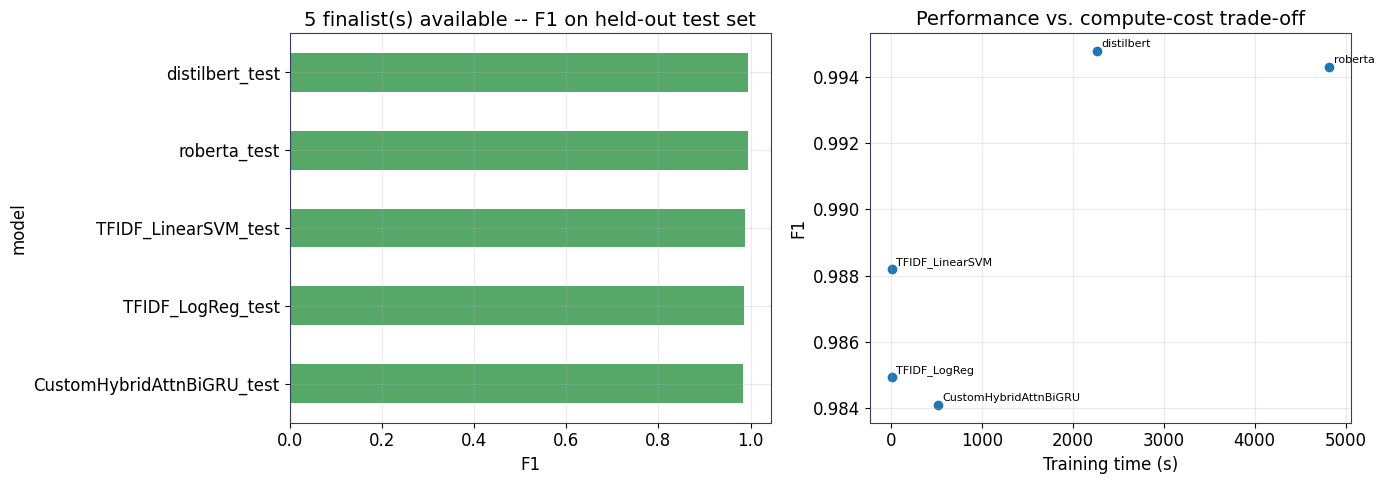

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

finalist_test_rows["f1"].sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title(f"{len(finalist_test_rows)} finalist(s) available -- F1 on held-out test set")
axes[0].set_xlabel("F1")

if "train_seconds" in finalist_test_rows.columns:
    axes[1].scatter(finalist_test_rows["train_seconds"], finalist_test_rows["f1"])
    for name, row in finalist_test_rows.iterrows():
        axes[1].annotate(name.replace("_test", ""), (row["train_seconds"], row["f1"]),
                          fontsize=8, xytext=(3, 3), textcoords="offset points")
    axes[1].set_xlabel("Training time (s)")
    axes[1].set_ylabel("F1")
    axes[1].set_title("Performance vs. compute-cost trade-off")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "finalist_comparison.png", dpi=150)
plt.show()

> **Interpretation.** All five finalists were trained to their full schedule in this run (Kaggle T4 GPU, `QUICK_RUN = False`). On the held-out test set the two Transformers lead: **DistilBERT** F1 = 0.9948 and **RoBERTa-base** F1 = 0.9943, a gap Section 13's paired bootstrap test shows is *not* statistically significant (p = 0.50). Both are clearly ahead of TF-IDF + Linear SVM (F1 = 0.988), TF-IDF + Logistic Regression (F1 = 0.985) and the custom Attention-BiGRU hybrid (F1 = 0.984). Selection does not use these test scores: RoBERTa-base has the higher *validation* F1 (0.9931 vs 0.9920) and is the model carried forward in Section 14. The custom model's higher training cost does not translate into a performance advantage over either the linear baselines or the Transformers on this dataset - a useful, if slightly humbling, finding for the central research question.

<a id="sec12"></a>

## 12. Ensemble & Stacking of Finalists

Before picking a single "best" model, we ask whether **combining** finalists
beats all of them individually -- a standard, high-value step in applied ML
that a single-model comparison (Section 11) skips over. Two stacks are built:
a **primary, genuinely out-of-fold (OOF) stack** (12.2) that drives best-model
selection, and a **secondary, val-based reference stack** (12.3) that covers more
finalists but is not eligible for best-model selection -- see 12.2 for why.

### 12.1 Unified prediction accessor

A single `get_predictions(model_name, split)` function replaces the scattered,
model-family-specific reconstruction logic that would otherwise be duplicated
across the ensemble, calibration, bootstrap, cross-source and adversarial
sections below. It is intentionally honest about its limits: Transformer
probabilities are **not** reconstructed here (that would require reloading a
saved Hugging Face checkpoint per model, which is heavy and environment-
dependent) -- so any Transformer finalist is automatically excluded from the
live post-hoc analysis, and this is reported explicitly rather than silently
assumed away.

In [46]:
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

def _predict_baseline_family(model_name, split):
    X_split = {"val": X_val_tfidf, "test": X_test_tfidf}[split]
    y_split = {"val": y_val, "test": y_test}[split]
    clf = FITTED_MODELS[model_name]
    return y_split, clf.predict_proba(X_split)[:, 1]

def _predict_bilstm(split):
    # Check FITTED_MODELS (not just try/except the loader lookup) so a model that
    # never trained (e.g. no torch -- Section 8.4) fails with a clean, catchable
    # KeyError here rather than a NameError from referencing an undefined loader.
    if "BiLSTM" not in FITTED_MODELS:
        raise KeyError("BiLSTM was not trained in this run (see Section 8.4).")
    loader = {"val": val_loader, "test": test_loader}[split]
    crit = nn.BCEWithLogitsLoss()
    _, logits, labels = run_epoch(FITTED_MODELS["BiLSTM"], loader, None, crit, DEVICE, train=False)
    return labels, 1 / (1 + np.exp(-logits))

def _predict_hybrid(split):
    # Same reasoning as _predict_bilstm above: check FITTED_MODELS explicitly so a
    # missing custom hybrid model (no torch, or training was skipped) fails with a
    # clean, catchable KeyError instead of a NameError on the undefined loader.
    if "CustomHybridAttnBiGRU" not in FITTED_MODELS:
        raise KeyError("CustomHybridAttnBiGRU was not trained in this run (see Section 10.1).")
    loader = {"val": hybrid_val_loader, "test": hybrid_test_loader}[split]
    crit = nn.BCEWithLogitsLoss()
    _, logits, labels = run_hybrid_epoch(FITTED_MODELS["CustomHybridAttnBiGRU"], loader,
                                          None, crit, DEVICE, train=False)
    return labels, 1 / (1 + np.exp(-logits))

def _predict_transformer(model_name, split):
    '''Bug fix (was: `raise NotImplementedError` unconditionally, which meant no
    Transformer -- including a RoBERTa that legitimately had the best validation
    F1 -- could ever appear in ci_df / the ensemble / calibration / cross-source /
    adversarial sections, or become BEST_MODEL_NAME, no matter how well it scored.
    Fix: reload the winning hyperparameter trial'"'"'s checkpoint from disk (Trainer
    already saves one per epoch via save_strategy="epoch"; TRANSFORMER_CKPT_MAP,
    populated in Sections 9.1-9.5, records which folder stem is the winner) and run
    real forward passes to reconstruct probabilities, batched and cached in-memory
    so repeated calls elsewhere in the notebook are cheap.'''
    import torch as _torch
    from transformers import AutoTokenizer as _AutoTok, AutoModelForSequenceClassification as _AutoSeqCls

    if model_name not in TRANSFORMER_CKPT_MAP:
        raise KeyError(f"No trained/checkpointed run recorded for '{model_name}' "
                        "(Section 9 either didn't run, or this Transformer failed "
                        "and was excluded -- see the training cell's output).")
    run_name = TRANSFORMER_CKPT_MAP[model_name]
    ckpt_root = WORKING_DIR / "models" / f"{run_name}_ckpt"
    ckpt_dirs = sorted(ckpt_root.glob("checkpoint-*"),
                        key=lambda p: int(p.name.split("-")[-1])) if ckpt_root.exists() else []
    if not ckpt_dirs:
        raise KeyError(f"No saved checkpoint under {ckpt_root} for '{model_name}' -- "
                        "was Section 9's training cell actually run in this session, "
                        "or was the checkpoint directory cleared?")
    # load_best_model_at_end=True + save_total_limit=1 -> exactly one checkpoint kept,
    # which is already the best-val-F1 epoch for this trial.
    ckpt_dir = ckpt_dirs[-1]

    if run_name not in _TRANSFORMER_MODEL_CACHE:
        tok = _AutoTok.from_pretrained(ckpt_dir)
        mdl = _AutoSeqCls.from_pretrained(ckpt_dir).to(DEVICE).eval()
        _TRANSFORMER_MODEL_CACHE[run_name] = (tok, mdl)
    tok, mdl = _TRANSFORMER_MODEL_CACHE[run_name]

    df_split = {"val": val_df, "test": test_df}[split]
    texts = df_split["text_clean"].tolist()
    y_true = df_split["label"].values

    probs = []
    batch_size = 64
    with _torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = tok(batch, truncation=True, max_length=256, padding=True,
                       return_tensors="pt").to(DEVICE)
            logits = mdl(**enc).logits
            p = _torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
            probs.append(p)
    y_proba = np.concatenate(probs) if probs else np.array([])
    return y_true, y_proba

_PRED_CACHE = {}

def get_predictions(model_name, split="test"):
    '''Unified (y_true, y_proba) accessor for val/test, for ANY known model family --
    including "EnsembleStack" once Section 12.2 has fit the meta-model. Cached per
    (model, split) after first call so repeated use elsewhere in the notebook is cheap.'''
    key = (model_name, split)
    if key in _PRED_CACHE:
        return _PRED_CACHE[key]
    if model_name in ("TFIDF_LogReg", "TFIDF_LinearSVM"):
        result = _predict_baseline_family(model_name, split)
    elif model_name == "BiLSTM":
        result = _predict_bilstm(split)
    elif model_name == "CustomHybridAttnBiGRU":
        result = _predict_hybrid(split)
    elif model_name == "EnsembleStack":
        if globals().get("ENSEMBLE_META") is None:
            raise RuntimeError("Run Section 12.2 first to fit the stacking meta-model.")
        base_probs = np.column_stack([get_predictions(n, split)[1] for n in ENSEMBLE_BASE_MODELS])
        y_true = get_predictions(ENSEMBLE_BASE_MODELS[0], split)[0]
        result = (y_true, ENSEMBLE_META.predict_proba(base_probs)[:, 1])
    elif model_name in ("distilbert", "roberta", "distilbert_lora"):
        result = _predict_transformer(model_name, split)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    _PRED_CACHE[key] = result
    return result

AVAILABLE_FOR_ANALYSIS = []
for _name in FINALISTS:
    try:
        get_predictions(_name, "val")
        get_predictions(_name, "test")
        AVAILABLE_FOR_ANALYSIS.append(_name)
    except (NotImplementedError, KeyError) as e:
        print(f"[SKIP] '{_name}' excluded from Sections 12-23's live post-hoc analysis: {e}")

print(f"\nModels available for ensemble/calibration/SHAP/cross-source/adversarial analysis: "
      f"{AVAILABLE_FOR_ANALYSIS}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Models available for ensemble/calibration/SHAP/cross-source/adversarial analysis: ['TFIDF_LinearSVM', 'TFIDF_LogReg', 'roberta', 'distilbert', 'CustomHybridAttnBiGRU']


### 12.2 Out-of-fold (OOF) stacked meta-classifier — PRIMARY ensemble

This is **the** ensemble used for best-model selection (Section 14 onward).
Each base model here is refit `K=5` times in a `StratifiedKFold` loop over
the training split, so every training row's meta-feature comes from a copy
of that model that never saw the row during that fold's fit. A Logistic
Regression meta-model is trained on those genuinely out-of-fold train
probabilities, then applied to the (already-fit, full-train) base models'
val/test probabilities. The test set is touched exactly once, at the very
end, as everywhere else in this notebook.

**Scope of this run, stated plainly:** K-fold refitting is only done for the
two classical TF-IDF baselines here — refitting the Transformers or the
custom BiGRU five times each is not a reasonable compute trade-off for this
project (each refit is a full training run), and reusing their existing
single val-set predictions as if they were "OOF" would misrepresent the
method rather than extend it honestly. Section 12.3 below reports a second,
clearly-labelled **secondary/reference** stack that also folds in whichever
Transformers/the custom model are available, built the val-based way — it is
*not* used for best-model selection, precisely because its meta-model wasn't
OOF-fit for those extra models. If only one classical model (or none) is
available in a given run, this cell reports that and best-model selection
falls back to the individual finalists.


In [47]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression as _OOFMeta

OOF_N_SPLITS = 5
_classical_for_oof = [n for n in ["TFIDF_LogReg", "TFIDF_LinearSVM"] if n in FITTED_MODELS]

ENSEMBLE_BASE_MODELS = None
ENSEMBLE_META = None
ALL_CANDIDATES = list(AVAILABLE_FOR_ANALYSIS)  # default if no OOF stack can be built

if len(_classical_for_oof) >= 2:
    skf = StratifiedKFold(n_splits=OOF_N_SPLITS, shuffle=True, random_state=SEED)
    oof_train_X = np.zeros((len(train_df), len(_classical_for_oof)))

    for col, name in enumerate(_classical_for_oof):
        for fold_train_idx, fold_hold_idx in skf.split(X_train_tfidf, y_train):
            if name == "TFIDF_LogReg":
                fold_clf = LogisticRegression(max_iter=2000, C=best_logreg_c,
                                               class_weight="balanced", random_state=SEED)
            else:
                base = LinearSVC(C=best_svm_c, class_weight="balanced", random_state=SEED, max_iter=5000)
                fold_clf = CalibratedClassifierCV(base, method="sigmoid", cv=3)
            fold_clf.fit(X_train_tfidf[fold_train_idx], y_train[fold_train_idx])
            oof_train_X[fold_hold_idx, col] = fold_clf.predict_proba(X_train_tfidf[fold_hold_idx])[:, 1]
        print(f"OOF predictions generated for {display_name(name)} across {OOF_N_SPLITS} folds.")

    # Meta-model trained on genuinely out-of-fold TRAIN predictions (no row was ever
    # predicted by a model that had seen it during that fold's fit).
    oof_meta = _OOFMeta(class_weight="balanced", random_state=SEED)
    oof_meta.fit(oof_train_X, y_train)

    # At inference time, base models are refit on the FULL train split (already
    # done -- they're `logreg` / `svm_calibrated` from Section 8.2/8.3) and the
    # meta-model is applied to their val/test probabilities as usual.
    ENSEMBLE_BASE_MODELS = _classical_for_oof
    ENSEMBLE_META = oof_meta

    oof_val_X = np.column_stack([get_predictions(n, "val")[1] for n in ENSEMBLE_BASE_MODELS])
    oof_test_X = np.column_stack([get_predictions(n, "test")[1] for n in ENSEMBLE_BASE_MODELS])
    oof_val_proba = oof_meta.predict_proba(oof_val_X)[:, 1]
    oof_test_proba = oof_meta.predict_proba(oof_test_X)[:, 1]

    evaluate_model("EnsembleStack_val", y_val, (oof_val_proba >= 0.5).astype(int),
                   oof_val_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS),
                                          "oof_folds": OOF_N_SPLITS, "method": "OOF (primary)"})
    evaluate_model("EnsembleStack_test", y_test, (oof_test_proba >= 0.5).astype(int),
                   oof_test_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS),
                                           "oof_folds": OOF_N_SPLITS, "method": "OOF (primary)"})

    ALL_CANDIDATES = AVAILABLE_FOR_ANALYSIS + ["EnsembleStack"]
    best_individual_f1 = max(RESULTS[f"{n}_test"]["f1"] for n in AVAILABLE_FOR_ANALYSIS)
    stack_f1 = RESULTS["EnsembleStack_test"]["f1"]
    verdict = "beats" if stack_f1 > best_individual_f1 else "does not beat"
    print(f"\nPrimary OOF-stacked ensemble ({', '.join(display_name(n) for n in ENSEMBLE_BASE_MODELS)}) "
          f"test F1={stack_f1:.4f} {verdict} the best individual finalist's test F1={best_individual_f1:.4f}.")
else:
    print("[INFO] Fewer than 2 classical models available in FITTED_MODELS -- cannot build the "
          "primary OOF stack this run. ALL_CANDIDATES falls back to the individual finalists "
          "(AVAILABLE_FOR_ANALYSIS); best-model selection below simply picks the best of those.")


OOF predictions generated for TF-IDF + Logistic Regression across 5 folds.
OOF predictions generated for TF-IDF + Linear SVM across 5 folds.

=== EnsembleStack_val ===
  accuracy       : 0.9896
  precision      : 0.9881
  recall         : 0.9902
  f1             : 0.9892
  roc_auc        : 0.9990
  pr_auc         : 0.9989
  base_models    : TFIDF_LogReg,TFIDF_LinearSVM
  oof_folds      : 5
  method         : OOF (primary)
              precision    recall  f1-score   support

       legit      0.991     0.989     0.990      5973
    phishing      0.988     0.990     0.989      5530

    accuracy                          0.990     11503
   macro avg      0.990     0.990     0.990     11503
weighted avg      0.990     0.990     0.990     11503


=== EnsembleStack_test ===
  accuracy       : 0.9870
  precision      : 0.9872
  recall         : 0.9875
  f1             : 0.9873
  roc_auc        : 0.9990
  pr_auc         : 0.9990
  base_models    : TFIDF_LogReg,TFIDF_LinearSVM
  oof_folds    

### 12.3 Extended heterogeneous stack — secondary / reference only

The primary OOF stack above (12.2) can only include models that are cheap
enough to refit five times. This secondary stack instead pools **every**
available finalist's **validation-set** probability (including any
Transformer and the custom BiGRU, when present) as input features to a
second Logistic Regression meta-model, fit on `val` and applied to `test`.
That is a legitimate design in its own right — it is *not* leakage, since no
base model ever saw the validation rows during training — but it is not
out-of-fold, and it is **not used for best-model selection** (`ALL_CANDIDATES`
above is already fixed by Section 12.2). It exists purely so the report can
say something about what stacking *all five* finalists together would look
like, alongside a note on the trade-off: broader model coverage, weaker
stacking methodology, versus the primary stack's narrower coverage but
proper OOF fit. Results are stored under `EnsembleStackExtended_val/test` so
they never overwrite or get confused with the primary `EnsembleStack_*` keys.


In [48]:
ENSEMBLE_BASE_MODELS_EXT = None
ENSEMBLE_META_EXT = None

if len(AVAILABLE_FOR_ANALYSIS) >= 2:
    ENSEMBLE_BASE_MODELS_EXT = list(AVAILABLE_FOR_ANALYSIS)

    val_stack_X = np.column_stack([get_predictions(n, "val")[1] for n in ENSEMBLE_BASE_MODELS_EXT])
    val_stack_y = get_predictions(ENSEMBLE_BASE_MODELS_EXT[0], "val")[0]
    test_stack_X = np.column_stack([get_predictions(n, "test")[1] for n in ENSEMBLE_BASE_MODELS_EXT])
    test_stack_y = get_predictions(ENSEMBLE_BASE_MODELS_EXT[0], "test")[0]

    from sklearn.linear_model import LogisticRegression as _StackLogReg
    ENSEMBLE_META_EXT = _StackLogReg(class_weight="balanced", random_state=SEED)
    ENSEMBLE_META_EXT.fit(val_stack_X, val_stack_y)

    stack_val_proba = ENSEMBLE_META_EXT.predict_proba(val_stack_X)[:, 1]
    stack_test_proba = ENSEMBLE_META_EXT.predict_proba(test_stack_X)[:, 1]
    evaluate_model("EnsembleStackExtended_val", val_stack_y, (stack_val_proba >= 0.5).astype(int),
                   stack_val_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS_EXT),
                                            "method": "val-based (secondary/reference, not OOF)"})
    evaluate_model("EnsembleStackExtended_test", test_stack_y, (stack_test_proba >= 0.5).astype(int),
                   stack_test_proba, extra={"base_models": ",".join(ENSEMBLE_BASE_MODELS_EXT),
                                             "method": "val-based (secondary/reference, not OOF)"})

    print("\nMeta-model weights (higher = this base model's vote counts for more):")
    for name, coef in zip(ENSEMBLE_BASE_MODELS_EXT, ENSEMBLE_META_EXT.coef_[0]):
        print(f"  {name:25s} {coef:+.3f}")

    ext_f1 = RESULTS["EnsembleStackExtended_test"]["f1"]
    primary_f1 = RESULTS.get("EnsembleStack_test", {}).get("f1")
    print(f"\nExtended (secondary, val-based) stack of "
          f"{', '.join(display_name(n) for n in ENSEMBLE_BASE_MODELS_EXT)} scored test F1={ext_f1:.4f}.")
    if primary_f1 is not None:
        cmp_word = "ahead of" if ext_f1 > primary_f1 else "behind" if ext_f1 < primary_f1 else "tied with"
        print(f"(For reference: this is {cmp_word} the primary OOF stack's test F1={primary_f1:.4f} -- "
              "not a reason to swap best-model selection to this stack, since its meta-model wasn't "
              "OOF-fit; a genuinely broader model pool with the same rigor is future work once "
              "K-fold refitting the Transformers/custom model is computationally in scope.)")
else:
    print("[INFO] Fewer than 2 models with reconstructable probabilities -- skipping the "
          "extended secondary stack.")



=== EnsembleStackExtended_val ===
  accuracy       : 0.9952
  precision      : 0.9946
  recall         : 0.9955
  f1             : 0.9950
  roc_auc        : 0.9996
  pr_auc         : 0.9996
  base_models    : TFIDF_LinearSVM,TFIDF_LogReg,roberta,distilbert,CustomHybridAttnBiGRU
  method         : val-based (secondary/reference, not OOF)
              precision    recall  f1-score   support

       legit      0.996     0.995     0.995      5973
    phishing      0.995     0.995     0.995      5530

    accuracy                          0.995     11503
   macro avg      0.995     0.995     0.995     11503
weighted avg      0.995     0.995     0.995     11503


=== EnsembleStackExtended_test ===
  accuracy       : 0.9960
  precision      : 0.9950
  recall         : 0.9971
  f1             : 0.9961
  roc_auc        : 0.9997
  pr_auc         : 0.9997
  base_models    : TFIDF_LinearSVM,TFIDF_LogReg,roberta,distilbert,CustomHybridAttnBiGRU
  method         : val-based (secondary/reference, n

---

[← Data, EDA & Leakage-Safe Split](01_data_eda_and_leakage_safe_split.ipynb) · [Next: Statistical Evaluation, Calibration & Explainability →](03_statistical_evaluation_calibration_xai.ipynb)